#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import pickle
import warnings
import os
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings('ignore')

from kmrf import KMRF
from KMRF_training_config import *
from SIMULATOR import SIMULATOR
from OPTIMIZER_INPUTS import OPTIMIZER_INPUTS
from BACKTEST import BACKTEST, generate_rebalance_dates


# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## Multi-Horizon Regime Predictions

#### Global Vars and Helper Functions

In [2]:
KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')
KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')

# Using saved KAMA+MSR models
def get_KM_model_dates(KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')) -> pd.Series:
    return pd.Series([f.stem for f in list(KM_MODEL_BASE_PATH.glob('*'))]).sort_values().iloc[1:].reset_index(drop=True)

def get_KM_model_paths(MODEL_DATE: str, KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')) ->  pd.Series:
    return pd.Series(list((KM_MODEL_BASE_PATH / MODEL_DATE).glob('*'))).sort_values().reset_index(drop=True)

# Using saved KMRF predictions
def get_asset_names(KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')) -> pd.Series:
    kmrf_preds_paths = list(KMRF_PREDICTIONS_BASE_PATH.glob('*'))
    return pd.Series([f.stem.split('multi')[0][:-1].replace('_', ' ') for f in kmrf_preds_paths]).sort_values().reset_index(drop=True)

def get_KMRF_prediction_paths(KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')) -> pd.Series:
    return pd.Series(list(KMRF_PREDICTIONS_BASE_PATH.glob('*'))).sort_values().reset_index(drop=True)

In [3]:
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

TRADING_DAYS = CustomBusinessDay(calendar=USFederalHolidayCalendar())

#### --------------------------------------------------------

In [4]:
RISK_FREE_RATES = pd.read_csv('data/risk_free_rates.csv', parse_dates=['Date'], index_col='Date')
RISK_FREE_RATES = RISK_FREE_RATES['RF_3M'].rename('RF').to_frame()

In [5]:
KM_MODEL_DATES = get_KM_model_dates()
ASSET_NAMES = get_asset_names()

display(ASSET_NAMES)

0     Consumer Discretionary Select Sector SPDR
1           Consumer Staples Select Sector SPDR
2                     Energy Select Sector SPDR
3                  Financial Select Sector SPDR
4                Health Care Select Sector SPDR
5                 Industrial Select Sector SPDR
6                        Invesco DB Agriculture
7                             Invesco QQQ Trust
8                  Materials Select Sector SPDR
9         SPDR Dow Jones Industrial Average ETF
10                             SPDR Gold Shares
11                             SPDR S&P 500 ETF
12                Technology Select Sector SPDR
13               United States Natural Gas Fund
14                       United States Oil Fund
15                 Utilities Select Sector SPDR
16          Vanguard FTSE Developed Markets ETF
17           Vanguard FTSE Emerging Markets ETF
18                     Vanguard FTSE Europe ETF
19                  iShares China Large-Cap ETF
20                       iShares MSCI In

In [6]:
KM_MODEL_DATES.iloc[-12]

'20241101'

In [7]:
PORTFOLIO_ASSETS = ['Technology Select Sector SPDR', 'Health Care Select Sector SPDR', 'Financial Select Sector SPDR',
                    'Consumer Discretionary Select Sector SPDR', 'Consumer Staples Select Sector SPDR', 
                    'Industrial Select Sector SPDR', 'Energy Select Sector SPDR', 'Utilities Select Sector SPDR',
                    'Materials Select Sector SPDR', 'iShares U.S. Real Estate ETF']
# Add a day first because optimization dates are the first day of the prediction period
# even though we want to optimize at the end of the previous trading day
# e.g., optimize on 2018-12-31 for the 21 trading day period starting 2019-01-02
# Risk-free rate is taken from the previous trading day
OPT_DATE = pd.Timestamp(KM_MODEL_DATES.iloc[-12]) + TRADING_DAYS
RISK_FREE = RISK_FREE_RATES.loc[OPT_DATE - TRADING_DAYS].values[0]
OPT_INPUTS = OPTIMIZER_INPUTS(opt_date=OPT_DATE, asset_list=PORTFOLIO_ASSETS, risk_free_rate=RISK_FREE, 
                              n_days=21, n_simulations=250, random_seed=42)
print("Optimization Date:", OPT_INPUTS.opt_date.date())
print(f"Risk-Free Rate ({(OPT_DATE - TRADING_DAYS).date()}):", OPT_INPUTS.risk_free_rate)

Optimization Date: 2024-11-04
Risk-Free Rate (2024-11-01): 0.0461


In [8]:
OPT_INPUTS.run_full_pipeline()


################################################################################
# OPTIMIZER INPUTS FULL PIPELINE
# Optimization Date: 2024-11-04
# Assets: 10
# Simulations: 250
# Horizon: 21 days
################################################################################

LOADING SIMULATORS FOR 10 ASSETS
Optimization Date: 2024-11-04
Model Date: 20241101
  [1/10] Loading Technology Select Sector SPDR...


KeyboardInterrupt: 

In [ ]:
OPT_INPUTS.optimize_portfolio(objective='max_sharpe', allow_short=True, gross_exposure=2)


PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 10
  Short selling: Allowed
  Gross exposure limit: 200.0%

  Optimization Results:
    Portfolio Return: 26.07%
    Portfolio Risk: 15.90%
    Sharpe Ratio: 1.350
    Sortino Ratio: 0.000

  Portfolio Weights:
    Consumer Discretionary Select Sector SPDR:   80.28%
    Technology Select Sector SPDR:   47.70%
    iShares U.S. Real Estate ETF:   16.05%
    Energy Select Sector SPDR:    4.40%
    Financial Select Sector SPDR:    1.57%
    Health Care Select Sector SPDR:  -22.86%
    Materials Select Sector SPDR:  -27.14%

✓ Portfolio optimized


In [ ]:
OPT_INPUTS.portfolio_summary()

,Weight,Expected Return,Return Contribution,Marginal Risk,Risk Contribution,Risk Contribution %
Consumer Discretionary Select Sector SPDR,0.8028,0.2128,0.1708,0.1369,0.1099,0.6913
Technology Select Sector SPDR,0.477,0.2157,0.1029,0.1390,0.0663,0.4172
Materials Select Sector SPDR,-0.2714,0.0922,-0.025,0.0743,-0.0202,-0.1269
Health Care Select Sector SPDR,-0.2286,0.0802,-0.0183,0.0655,-0.015,-0.0942
iShares U.S. Real Estate ETF,0.1605,0.1375,0.0221,0.0811,0.013,0.0819
Energy Select Sector SPDR,0.044,0.1313,0.0058,0.0765,0.0034,0.0212
Financial Select Sector SPDR,0.0157,0.1577,0.0025,0.0960,0.0015,0.0095
Industrial Select Sector SPDR,,0.1341,,0.0941,,
Utilities Select Sector SPDR,,0.0746,,0.0438,,
Consumer Staples Select Sector SPDR,,0.0946,,0.0532,,


(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Risk (Annualized Volatility)', ylabel='Expected Return (Annualized)'>)

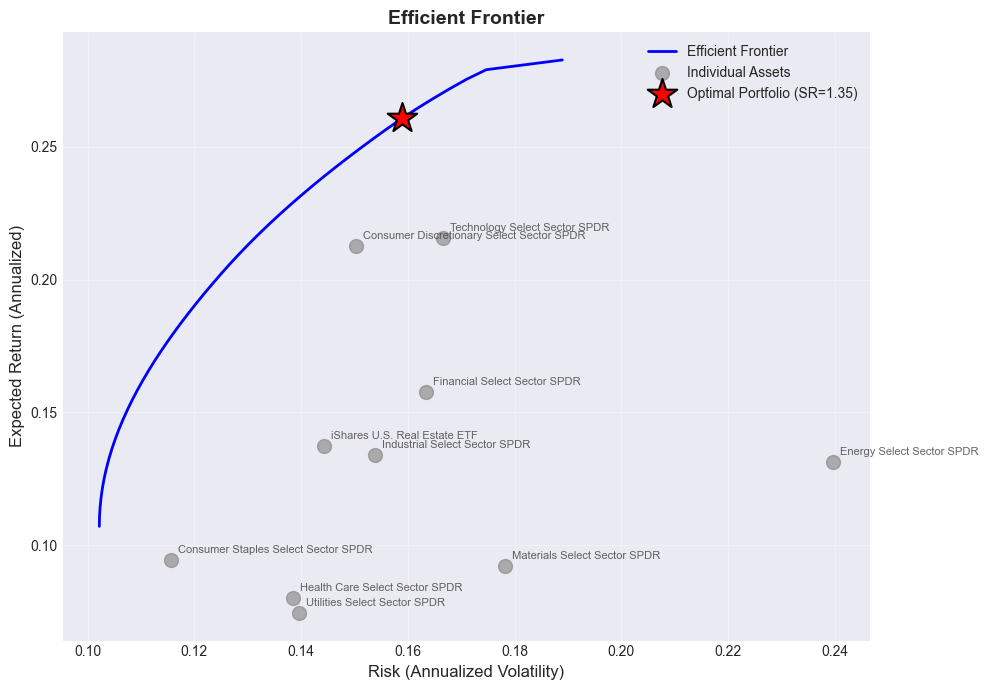

In [ ]:
OPT_INPUTS.plot_efficient_frontier()

In [ ]:
OPT_INPUTS.market_simulator.kmrf_predictions

model_end_date  P(LV_Bull)  P(LV_Bear)  \
date       horizon prediction_date                                          
2019-01-02 1       2019-01-02            20181231    0.005484    0.738907   
           2       2019-01-03            20181231    0.002844    0.772020   
           3       2019-01-04            20181231    0.003930    0.787103   
           4       2019-01-07            20181231    0.003230    0.802660   
           5       2019-01-08            20181231    0.002842    0.782096   
...                                           ...         ...         ...   
2025-10-31 17      2025-11-25            20251007    0.992879    0.001189   
           18      2025-11-26            20251007    0.991069    0.001485   
           19      2025-11-28            20251007    0.990190    0.001576   
           20      2025-12-01            20251007    0.992680    0.001024   
           21      2025-12-02            20251007    0.990339    0.001413   

                                    P(HV_Bull)  P(HV_Bear)  
date       horizon prediction_date                          
2019-01-02 1       2019-01-02         0.015601    0.240008  
           2       2019-01-03         0.009267    0.215869  
           3       2019-01-04         0.008758    0.200209  
           4       2019-01-07         0.007942    0.186167  
           5       2019-01-08         0.005851    0.209211  
...                                        ...         ...  
2025-10-31 17      2025-11-25         0.003100    0.002832  
           18      2025-11-26         0.003692    0.003754  
           19      2025-11-28         0.003913    0.004321  
           20      2025-12-01         0.002428    0.003867  
           21      2025-12-02         0.002538    0.005709  

[36099 rows x 5 columns]

#### --------------------------------------------------------

In [4]:
KM_MODEL_DATES = get_KM_model_dates()
get_asset_names()

0     Consumer Discretionary Select Sector SPDR
1           Consumer Staples Select Sector SPDR
2                     Energy Select Sector SPDR
3                  Financial Select Sector SPDR
4                Health Care Select Sector SPDR
5                 Industrial Select Sector SPDR
6                        Invesco DB Agriculture
7                             Invesco QQQ Trust
8                  Materials Select Sector SPDR
9         SPDR Dow Jones Industrial Average ETF
10                             SPDR Gold Shares
11                             SPDR S&P 500 ETF
12                Technology Select Sector SPDR
13               United States Natural Gas Fund
14                       United States Oil Fund
15                 Utilities Select Sector SPDR
16          Vanguard FTSE Developed Markets ETF
17           Vanguard FTSE Emerging Markets ETF
18                     Vanguard FTSE Europe ETF
19                  iShares China Large-Cap ETF
20                       iShares MSCI In

In [5]:
PORTFOLIO_ASSETS = ['SPDR S&P 500 ETF', 'iShares Russell 2000 ETF',
                    'Vanguard FTSE Developed Markets ETF', 'Vanguard FTSE Emerging Markets ETF',
                    'iShares U.S. Real Estate ETF', 'SPDR Gold Shares']
START = pd.Timestamp(KM_MODEL_DATES.iloc[0]) + TRADING_DAYS
# END = pd.Timestamp(KM_MODEL_DATES.iloc[-1])
END  = pd.Timestamp('2025-10-31')
print("start date:", START.date(), "\nend date:", END.date())



start date: 2019-01-02 
end date: 2025-10-31


In [6]:
bt = BACKTEST(backtest_start=START, backtest_end=END,
              asset_list=PORTFOLIO_ASSETS,
              rebalance_frequency='monthly',
              objective='max_sharpe', allow_short=False, gross_exposure=None,
              n_days=21, n_simulations=250, 
              initial_capital=100_000.0, transaction_cost_bps=0.0,
              use_regime_trigger=True, regime_change_threshold=0.25,
              max_intermediate_rebalances=4,
              random_seed=123)

In [ ]:
# Run the backtest
bt.run_parallel(n_cpus=6,verbose=True)

RUNNING BACKTEST (PARALLEL MODE)
Period: 2019-01-02 to 2025-10-31
Assets: 6
Standard Rebalances: 82
Objective: max_sharpe
Allow Short: False, Gross Exposure: None
Regime Trigger: Enabled (threshold=0.25)
Max Intermediate Rebalances per Period: 4
Parallel Workers: 6

[Parallel] Processing 82 periods with optimizations and regime triggers...


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.



PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 13.40%
    Portfolio Risk: 13.88%
    Sharpe Ratio: 0.791
    Sortino Ratio: 1.173

  Portfolio Weights:
    SPDR Gold Shares:   41.92%
    iShares U.S. Real Estate ETF:   32.94%
    iShares Russell 2000 ETF:   25.14%

✓ Portfolio optimized


[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  1.0min



PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 15.55%
    Portfolio Risk: 13.94%
    Sharpe Ratio: 0.943
    Sortino Ratio: 1.382

  Portfolio Weights:
    Vanguard FTSE Emerging Markets ETF:   46.09%
    SPDR Gold Shares:   41.44%
    iShares Russell 2000 ETF:   12.47%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 10.21%
    Portfolio Risk: 11.17%
    Sharpe Ratio: 0.704
    Sortino Ratio: 1.006

  Portfolio Weights:
    SPDR S&P 500 ETF:   65.59%
    iShares U.S. Real Estate ETF:   19.06%
    SPDR Gold Shares:   15.35%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 9.80%
    Portfolio Risk: 13.56%
    Sharpe Ratio: 0.543
    Sortino Ratio: 0.768

  Portfolio Weights:
    SPDR

...


PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 15.66%
    Portfolio Risk: 14.93%
    Sharpe Ratio: 1.045
    Sortino Ratio: 1.538

  Portfolio Weights:
    SPDR Gold Shares:   60.37%
    Vanguard FTSE Emerging Markets ETF:   39.63%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 15.34%
    Portfolio Risk: 11.05%
    Sharpe Ratio: 1.384
    Sortino Ratio: 2.033

  Portfolio Weights:
    SPDR S&P 500 ETF:   62.44%
    SPDR Gold Shares:   29.78%
    iShares U.S. Real Estate ETF:    5.57%
    Vanguard FTSE Emerging Markets ETF:    2.22%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 11.38%
    Portfolio Risk: 11.19%
    Sharpe Ratio: 1.013
    Sortino Ratio: 1.439

  Portfolio Weight

[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed: 58.0min



PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 13.26%
    Portfolio Risk: 11.67%
    Sharpe Ratio: 1.090
    Sortino Ratio: 1.581

  Portfolio Weights:
    SPDR S&P 500 ETF:   53.06%
    SPDR Gold Shares:   38.05%
    Vanguard FTSE Developed Markets ETF:    8.89%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 22.68%
    Portfolio Risk: 13.93%
    Sharpe Ratio: 1.601
    Sortino Ratio: 2.422

  Portfolio Weights:
    SPDR Gold Shares:   43.69%
    Vanguard FTSE Developed Markets ETF:   41.76%
    iShares Russell 2000 ETF:    9.03%
    SPDR S&P 500 ETF:    5.52%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 14.52%
    Portfolio Risk: 17.38%
    Sharpe Ratio: 0.592
    Sortino Rat

[Parallel(n_jobs=6)]: Done  49 tasks      | elapsed: 101.0min



PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 20.33%
    Portfolio Risk: 15.08%
    Sharpe Ratio: 1.320
    Sortino Ratio: 1.929

  Portfolio Weights:
    SPDR Gold Shares:   85.65%
    Vanguard FTSE Developed Markets ETF:   14.35%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 18.18%
    Portfolio Risk: 16.94%
    Sharpe Ratio: 0.762
    Sortino Ratio: 1.133

  Portfolio Weights:
    iShares Russell 2000 ETF:   68.24%
    SPDR Gold Shares:   31.76%

✓ Portfolio optimized

PORTFOLIO OPTIMIZATION
  Objective: max_sharpe
  Assets: 6
  Short selling: Not allowed

  Optimization Results:
    Portfolio Return: 15.03%
    Portfolio Risk: 11.56%
    Sharpe Ratio: 1.254
    Sortino Ratio: 1.851

  Portfolio Weights:
    iShares U.S. Real Estate ETF:   62.19%
    SPDR Gold Shares:   35.09%
    iS

In [ ]:
# Print performance summary
bt.print_summary()


BACKTEST PERFORMANCE SUMMARY
Period:             2024-11-04 to 2025-10-31
Trading Days:       249
Standard Rebalances: 12
Triggered Rebalances: 5
Total Rebalances:   17
------------------------------------------------------------
Initial Capital:    $100,000.00
Final Value:        $99,386.69
Total Return:       -0.61%
Annualized Return:  -0.62%
Annualized Vol:     19.37%
------------------------------------------------------------
Sharpe Ratio:       -0.255
Sortino Ratio:      -0.305
Max Drawdown:       -28.15%
Win Rate:           55.4%


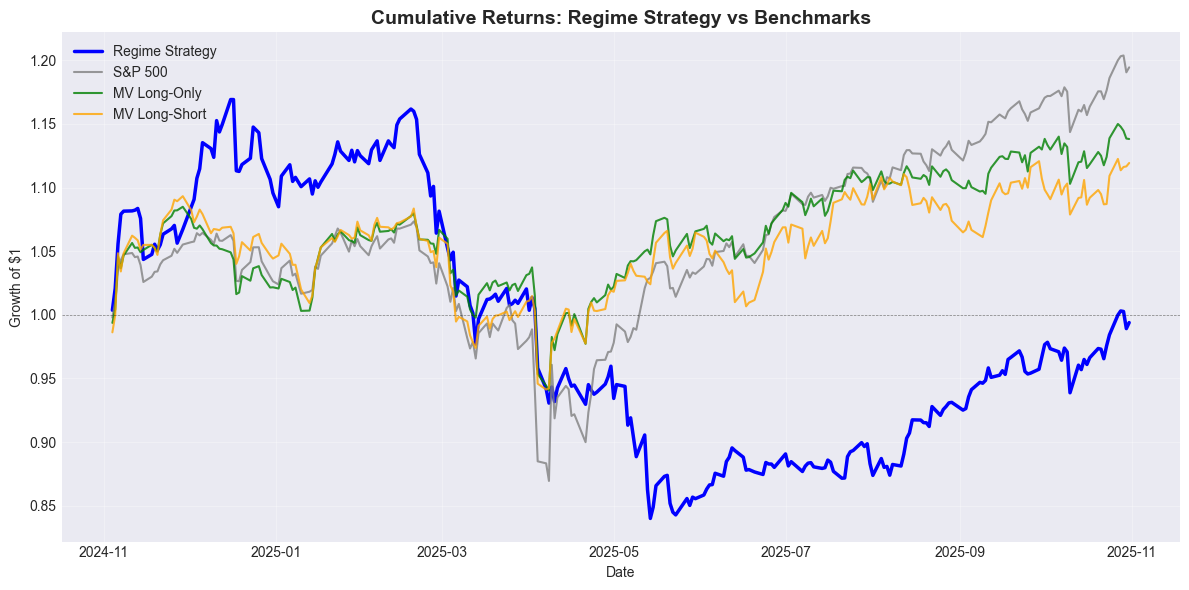

In [ ]:
# Plot cumulative returns vs benchmarks
bt.plot_performance()

In [ ]:
# View weights history at each rebalance
print("Portfolio Weights at Each Rebalance:")
display(bt.weights_history)

Portfolio Weights at Each Rebalance:


,Technology Select Sector SPDR,Health Care Select Sector SPDR,Financial Select Sector SPDR,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,Industrial Select Sector SPDR,Energy Select Sector SPDR,Utilities Select Sector SPDR,Materials Select Sector SPDR,iShares U.S. Real Estate ETF
date,,,,,,,,,,
2024-11-04,9.528046e-01,-0.013514,-7.648489e-10,3.439345e-01,-1.106286e-08,-3.586894e-09,7.136187e-09,-3.288071e-01,-1.576786e-01,2.032609e-01
2024-12-04,5.519704e-01,-0.272812,-2.271882e-01,8.093537e-01,-1.141934e-08,1.285073e-09,1.386759e-01,-4.207200e-09,1.384828e-08,-3.480740e-10
2025-01-06,3.920753e-01,0.605542,-4.258919e-01,3.806830e-01,-6.818493e-09,-7.410811e-02,-1.877487e-09,-1.334270e-08,6.830229e-02,5.339707e-02
2025-02-06,5.677069e-01,-0.270526,-1.099193e-08,5.067092e-01,-3.227520e-09,-2.294736e-01,7.898192e-02,3.466019e-01,-9.464756e-09,-4.643257e-09
2025-03-10,-2.719288e-01,-0.092269,-7.375634e-09,2.396665e-01,-4.362176e-09,-5.486115e-09,-5.653688e-09,-4.604446e-09,-1.358024e-01,1.260334e+00
2025-03-17,-3.760557e-01,0.913701,-1.751766e-02,2.471109e-01,-1.064266e-01,7.381554e-02,2.807615e-10,-1.639121e-08,-1.205553e-08,2.653724e-01
2025-04-08,-1.494083e-01,1.037319,-5.423630e-03,-6.627851e-10,3.686814e-01,-2.911314e-01,-5.403664e-02,4.176942e-02,-1.071145e-08,5.223003e-02
2025-04-25,-3.301555e-01,0.856769,-7.186476e-02,-7.823251e-02,5.272505e-10,1.986732e-01,-1.974719e-02,1.483091e-01,6.242388e-02,2.338250e-01
2025-05-02,-4.715880e-01,1.377433,-2.841195e-02,1.687068e-02,-1.247162e-08,3.422003e-10,-1.093016e-08,-1.049813e-08,-7.987586e-10,1.056967e-01


In [ ]:
# View rebalance types (standard vs triggered)
print("Rebalance Types:")
display(bt._rebalance_types)

Rebalance Types:


date
2024-11-04     standard
2024-12-04     standard
2025-01-06     standard
2025-02-06     standard
2025-03-10     standard
2025-03-17    triggered
2025-04-08     standard
2025-04-25    triggered
2025-05-02    triggered
2025-05-05    triggered
2025-05-08     standard
2025-05-13    triggered
2025-06-09     standard
2025-07-10     standard
2025-08-08     standard
2025-09-09     standard
2025-10-08     standard
Name: rebal_type, dtype: object

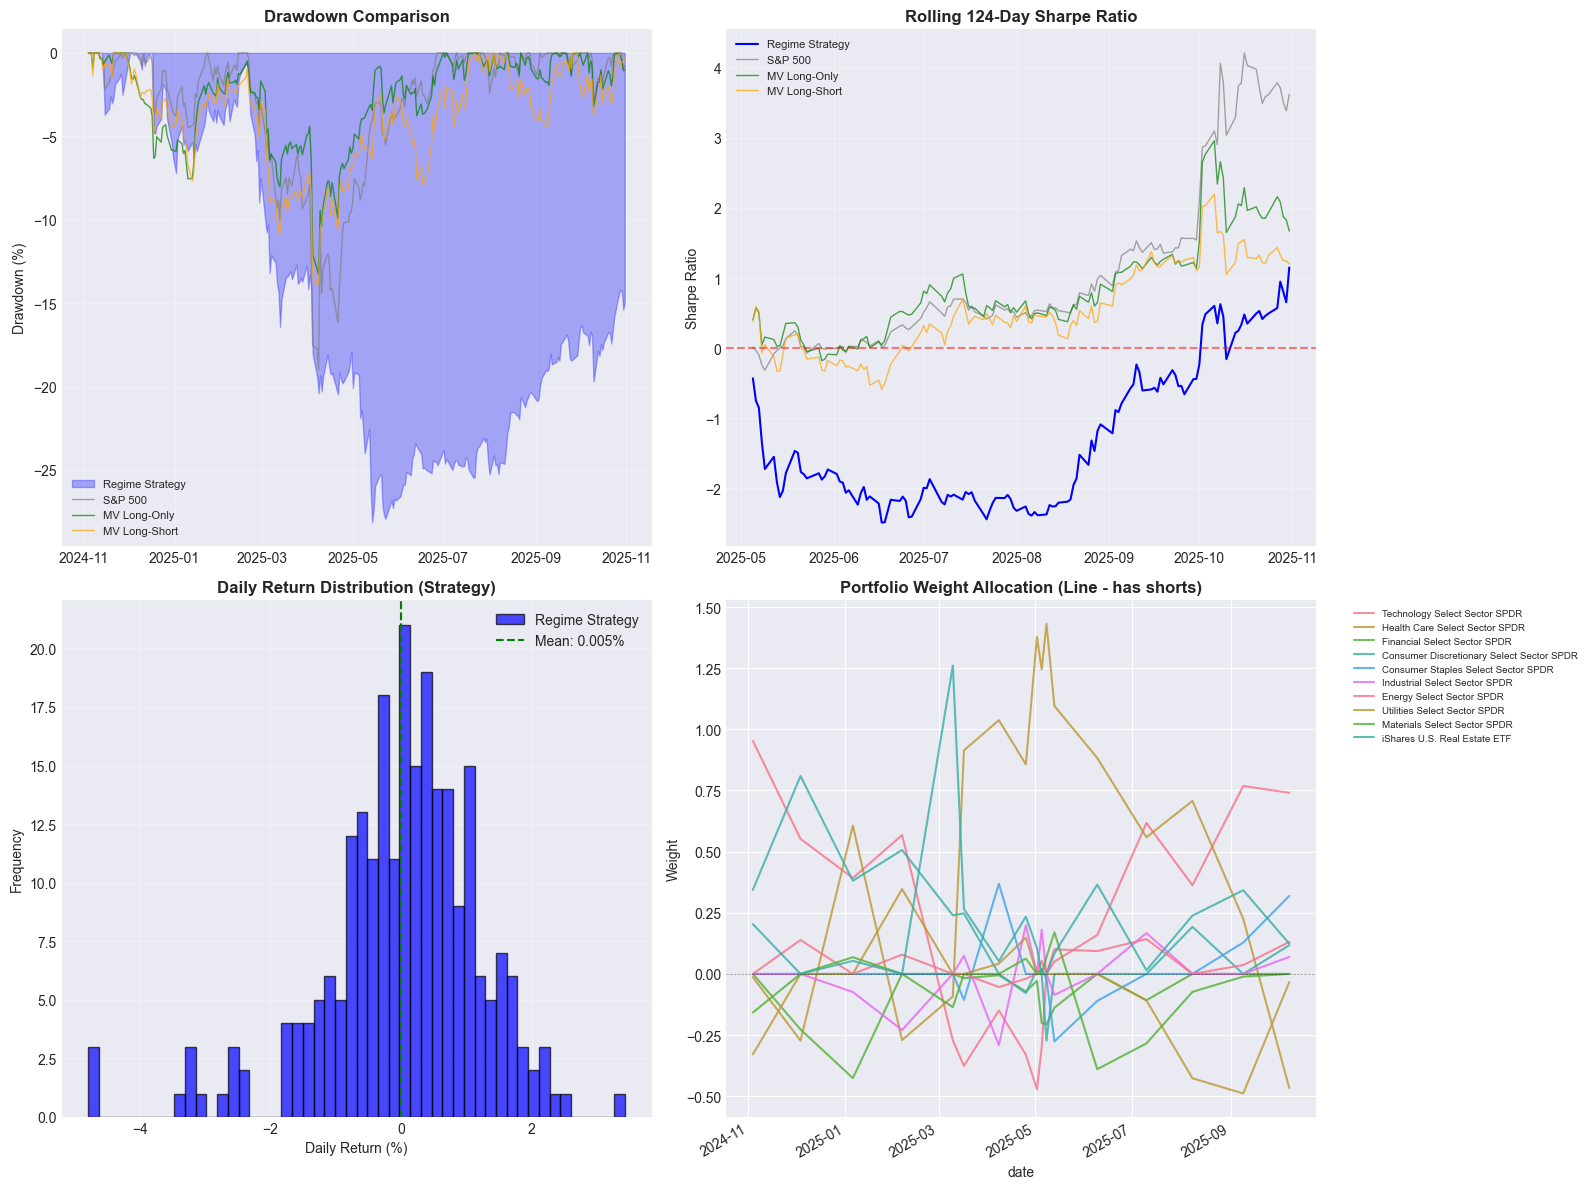

In [ ]:
# Plot detailed analysis (drawdowns, rolling Sharpe, return distribution, weights)
bt.plot_detailed_analysis()

In [ ]:
# Get performance metrics comparison
metrics_df = bt.get_metrics()
print("Performance Metrics Comparison:")
display(metrics_df)

Performance Metrics Comparison:


,Regime Strategy,S&P 500,MV Long-Only,MV Long-Short
Total Return,-0.009693,0.196995,0.145431,0.134901
Annualized Return,-0.009809,0.199592,0.147307,0.136633
Annualized Volatility,0.193698,0.196502,0.154014,0.167827
Sharpe Ratio,-0.273607,0.795939,0.676036,0.556795
Sortino Ratio,-0.327539,1.002446,0.869873,0.787354
Max Drawdown,-0.281546,-0.189989,-0.133100,-0.138972
Calmar Ratio,-0.034840,1.050542,1.106741,0.983172
Win Rate,0.554217,0.574297,0.526104,0.538153
Avg Daily Return,0.000050,0.000789,0.000567,0.000508
Skewness,-0.956937,1.443793,-0.522805,-0.237695


In [ ]:
# save the backtest object to a pickle file in backtests_v2/
filepath = f'backtests_v2/gen_gross-1_{START.strftime("%Y%m%d")}-{END.strftime("%Y%m%d")}.pkl'
with open(filepath, 'wb') as f:
    pickle.dump(bt, f)